# Counting the Breaks \U0001F6A8
### A 99% VaR promises to be wrong two days a year. Let's count.

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Partial](https://img.shields.io/badge/Tradability-Partial-dab617?style=flat-square)

Most risk numbers cannot be checked. Value-at-Risk can: it says the loss will exceed *this*
number on one day in a hundred, and you can count the days. So we counted — five standard
models, six assets, thirty years — and then asked the question that matters more than the
count itself: how wrong would a model have to be before we would even notice?

> \U0001F4D3 **This is the plain-language layer.** The likelihood-ratio tests, the clustering
> diagnostics and the power curve are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| Does the textbook normal VaR keep its promise? | No — it breaks far more often than advertised. |
| Is breaking too often the only problem? | No. The breaks also arrive in clusters. |
| Is there a model that works? | Filtered historical simulation comes closest. |
| Could we tell a good model from a mediocre one? | Often not. That is the uncomfortable part. |

## 1 · The promise

In [2]:
from breaks import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
assets = {tk: rets[tk].dropna() for tk in data.TICKERS
          if tk != data.CASH and rets[tk].notna().sum() > 1500}
spy = assets[data.EQUITY]
print(f"as-of {data.AS_OF} | {len(assets)} assets")
for tk, s in assets.items():
    print(f"  {tk:9s} {s.index[0].date()} -> {s.index[-1].date()}  n={len(s):,}  "
          f"worst day {s.min():.1%}  kurtosis {s.kurtosis():.1f}")

as-of 2026-06-30 | 6 assets
  SPY       1993-02-01 -> 2026-06-30  n=7,764  worst day -9.8%  kurtosis 11.3
  QQQ       1999-03-11 -> 2026-06-30  n=6,222  worst day -9.2%  kurtosis 6.9
  TLT       2002-07-31 -> 2026-06-30  n=5,371  worst day -6.7%  kurtosis 3.4
  GLD       2004-11-19 -> 2026-06-30  n=4,789  worst day -10.3%  kurtosis 6.9
  EEM       2003-04-15 -> 2026-06-30  n=5,193  worst day -16.2%  kurtosis 17.9
  BTC-USD   2014-09-18 -> 2026-06-30  n=4,304  worst day -37.2%  kurtosis 7.9


A 99% one-day VaR says: *tomorrow, you will lose more than this on 1% of days.* Over 30 years
of trading that is about 75 days. Not zero — the model is *supposed* to be wrong sometimes,
and a model that is never wrong is simply too conservative to be useful.

## 2 · What a breach looks like

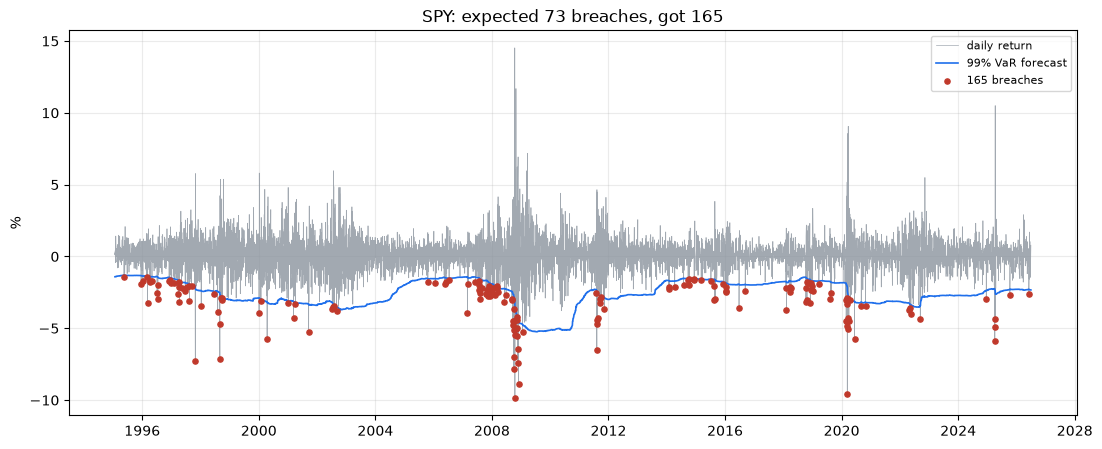

In [3]:
var = st.build_var(spy, "normal", 0.99, 500)
b = st.breaches(spy, var)
df = pd.concat([spy.rename("r"), var.rename("v")], axis=1, sort=False).dropna()
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(df.index, df["r"] * 100, lw=0.5, color="#8b949e", alpha=0.8, label="daily return")
ax.plot(df.index, -df["v"] * 100, lw=1.2, color="#1f6feb", label="99% VaR forecast")
hit = df[df["r"] < -df["v"]]
ax.scatter(hit.index, hit["r"] * 100, s=14, color="#c0392b", zorder=5,
           label=f"{len(hit)} breaches")
ax.set_ylabel("%"); ax.legend(fontsize=8)
ax.set_title(f"{data.EQUITY}: expected {len(df) * 0.01:.0f} breaches, got {len(hit)}")
plt.show()

> \U0001F52C **For the quants.** Look at *where* the red dots are, not just how many. They come
> in bunches. That is a second, separate failure — and it is the one that hurts, because it
> means the days the model is wrong are exactly the days you most need it to be right.

## 3 · Five models, graded

                        n  breaches  expected   rate  kupiec_p  independence_p  joint_p  max_consecutive
model                                                                                                   
historical           7264       107   72.6400 0.0147    0.0002          0.0000   0.0000                2
normal               7264       165   72.6400 0.0227    0.0000          0.0001   0.0000                2
student_t            7263       129   72.6300 0.0178    0.0000          0.0001   0.0000                2
ewma                 7264       140   72.6400 0.0193    0.0000          0.2000   0.0000                2
filtered_historical  7264       147   72.6400 0.0202    0.0000          0.2734   0.0000                2


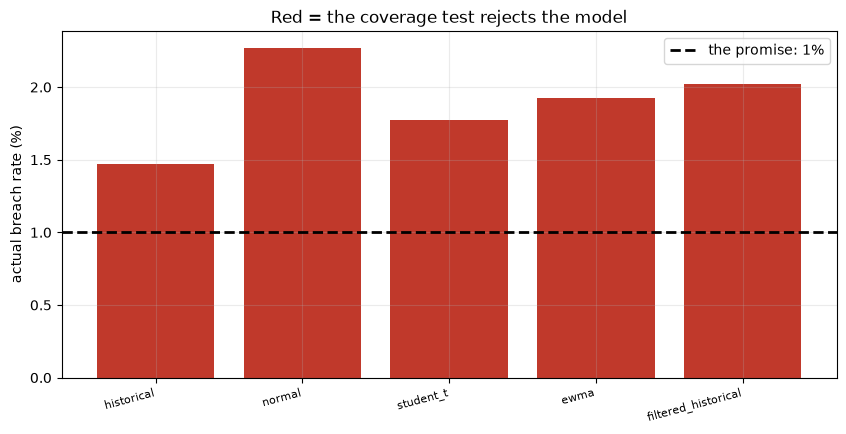

In [4]:
g = st.grade_all(spy, 0.99, 500)
print(g[["n", "breaches", "expected", "rate", "kupiec_p", "independence_p", "joint_p",
         "max_consecutive"]].round(4).to_string())
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(range(len(g)), g["rate"] * 100, color=np.where(g["kupiec_p"] < 0.05, "#c0392b",
                                                      "#2ea44f"))
ax.axhline(1.0, color="k", ls="--", lw=2, label="the promise: 1%")
ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index, rotation=15, ha="right", fontsize=8)
ax.set_ylabel("actual breach rate (%)"); ax.legend()
ax.set_title("Red = the coverage test rejects the model")
plt.show()

## 4 · Passing the count, failing the timing

Here is a model I made up. It breaches on *exactly* 1% of days — perfect coverage — but all its
breaches arrive in ten-day bursts.

In [5]:
n = 10000
fake = np.zeros(n, dtype=int)
for start in range(100, n, 1000):
    fake[start:start + 10] = 1
fake = pd.Series(fake)
k = st.kupiec_test(fake, 0.99)
c = st.christoffersen_independence(fake)
print(f"breach rate: {k['rate']:.2%} against a promised 1.00%")
print(f"Kupiec coverage test:   p = {k['p_value']:.3f}  -> "
      f"{'REJECT' if k['reject_5pct'] else 'passes'}")
print(f"Christoffersen indep.:  p = {c['p_value']:.3f}  -> "
      f"{'REJECT' if c['reject_5pct'] else 'passes'}")
print("\nA model that loses you money in ten-day runs, certified by the test most people run.")

breach rate: 1.00% against a promised 1.00%
Kupiec coverage test:   p = 1.000  -> passes
Christoffersen indep.:  p = 0.000  -> REJECT

A model that loses you money in ten-day runs, certified by the test most people run.


## 5 · The uncomfortable part

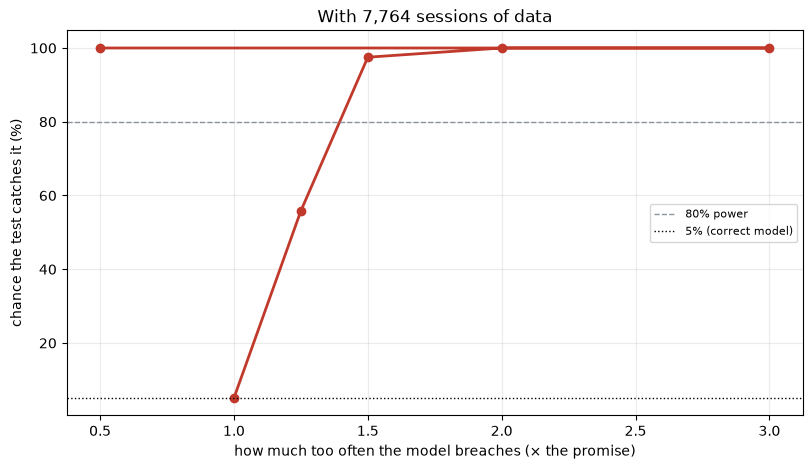

           ratio_to_promised  reject_rate  expected_breaches
true_rate                                                   
0.0100                1.0000       0.0508            77.6400
0.0125                1.2500       0.5583            97.0500
0.0150                1.5000       0.9750           116.4600
0.0200                2.0000       1.0000           155.2800
0.0300                3.0000       1.0000           232.9200
0.0050                0.5000       1.0000            38.8200


In [6]:
pc = st.power_curve(len(spy), 0.99, n_sims=1200)
fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(pc["ratio_to_promised"], pc["reject_rate"] * 100, "o-", lw=2, color="#c0392b")
ax.axhline(80, ls="--", color="#8b949e", lw=1, label="80% power")
ax.axhline(5, ls=":", color="k", lw=1, label="5% (correct model)")
ax.set_xlabel("how much too often the model breaches (× the promise)")
ax.set_ylabel("chance the test catches it (%)")
ax.legend(fontsize=8)
ax.set_title(f"With {len(spy):,} sessions of data")
plt.show()
print(pc.round(4).to_string())

A model that is **50% too loose** — breaching 1.5 days in a hundred instead of 1 — slips past
the test more often than not. To catch that reliably you would need decades more data than
anyone has.

## 6 · The verdict

**Signal: Confirmed.** At 99% confidence over 6 assets, the textbook **normal** VaR model breached on **1.95%** of days against a promised 1.00% — 1.9× too often — and Kupiec's coverage test rejected it on **100%** of assets. Worse, and this is the part standard practice never checks: the independence test rejected it on **83%**, with runs of up to 4 consecutive breaches. Those are two different failures — the distribution's shape is wrong *and* it does not know today's volatility — and a breach count alone cannot tell them apart. The best model here is **ewma** at 1.79%, passing the joint test on 17% of assets.

**Tradability: Partial.** Before switching models on this evidence, note how weak the evidence can be. With 5,282 sessions at 99%, a model that breaches **50% too often** (1.5% instead of 1.0%) is caught by Kupiec only **91%** of the time; detecting that reliably needs about **3,536 sessions** — 14 years. On the days the models were wrong they were wrong by a lot: the normal model's average breach overshot its own forecast by 40%, and its worst day lost 37.2% against a forecast of 8.3%. Breach counting says nothing about that, which is the argument for expected shortfall.

## 7 · Going further \U0001F6AA

- **Use expected shortfall.** VaR tells you how often you will be surprised, never by how much.
  Basel moved to ES for this reason.
- **Test at 95%, not 99%.** Five times the breaches means five times the statistical power. You
  learn far more about a model's quality at a level you can actually measure.
- **Duration tests.** Christoffersen & Pelletier (2004) test the gaps *between* breaches and
  catch clustering that a next-day test cannot see.